# 02 - Exploratory Analysis

Dataset: Amazon India product listings (1,351 unique products after cleaning).

Questions I want to answer:
1. How are prices and discounts distributed?
2. Which categories and sub-categories give the biggest discounts, and which are rated best?
3. Do heavy discounts go together with lower ratings?
4. Does price band make a difference to rating or discount?
5. Which brands are most common, and which have the best ratings?
6. Which products are the best (taking the number of ratings into account), and which look overpromised?
7. What do customers complain about, by sub-category?

**Note:** `rating_count` is the number of customer ratings, not sales. I use it only as a rough measure of how popular a product is.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
MAIN = "#2F6690"      # one main colour so the charts look consistent
ACCENT = "#D1495B"

df = pd.read_csv("../data/processed/amazon_products_clean.csv")

# keep the band order correct (otherwise they sort alphabetically)
price_order = ["Under 200", "200-500", "500-1000", "1000-2000", "2000-5000", "5000+"]
disc_order = ["0-20%", "21-40%", "41-60%", "61-80%", "81%+"]
df["price_band"] = pd.Categorical(df["price_band"], categories=price_order, ordered=True)
df["discount_band"] = pd.Categorical(df["discount_band"], categories=disc_order, ordered=True)

print(df.shape)
df.head(3)

(1351, 18)


,product_id,product_name,brand,main_category,sub_category,leaf_category,actual_price,discounted_price,discount_pct,amount_saved,price_band,discount_band,rating,rating_count,n_reviews,positive_per_review,negative_per_review,product_link
0,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Ambrane,Computers&Accessories,Accessories&Peripherals,USBCables,349.0,199.0,43,150.0,Under 200,41-60%,4.0,43994.0,8,2.125,0.000,https://www.amazon.in/Ambrane-Unbreakable-Char...
1,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Portronics,Computers&Accessories,Accessories&Peripherals,USBCables,399.0,154.0,61,245.0,Under 200,61-80%,4.2,16905.0,8,2.250,0.375,https://www.amazon.in/Portronics-Konnect-POR-1...
2,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,pTron,Computers&Accessories,Accessories&Peripherals,USBCables,1000.0,149.0,85,851.0,Under 200,81%+,3.9,24871.0,8,1.625,0.000,https://www.amazon.in/Solero-TB301-Charging-48...


## 1. Overall picture

In [2]:
df[["actual_price", "discounted_price", "discount_pct", "rating", "rating_count"]].describe().round(2)

,actual_price,discounted_price,discount_pct,rating,rating_count
count,1351.00,1351.00,1351.00,1350.00,1349.00
mean,5690.51,3304.65,46.68,4.09,17644.52
std,11218.92,7174.00,21.62,0.30,42145.66
min,39.00,39.00,0.00,2.00,2.00
25%,899.00,349.00,31.00,3.90,1106.00
50%,1790.00,899.00,49.00,4.10,4740.00
75%,4575.00,2174.00,62.00,4.30,16020.00
max,139900.00,77990.00,94.00,5.00,426973.00


**What I see:**
- The median selling price is Rs 899 but the mean is Rs 3,305. A few very expensive products pull the average up (max is Rs 77,990), so the median is the better number to quote.
- Median discount is 49% and median rating is 4.1 out of 5.
- `rating_count` is also very skewed: the median is 4,740 but the maximum is 4,26,973.

## 2. Price and discount distribution

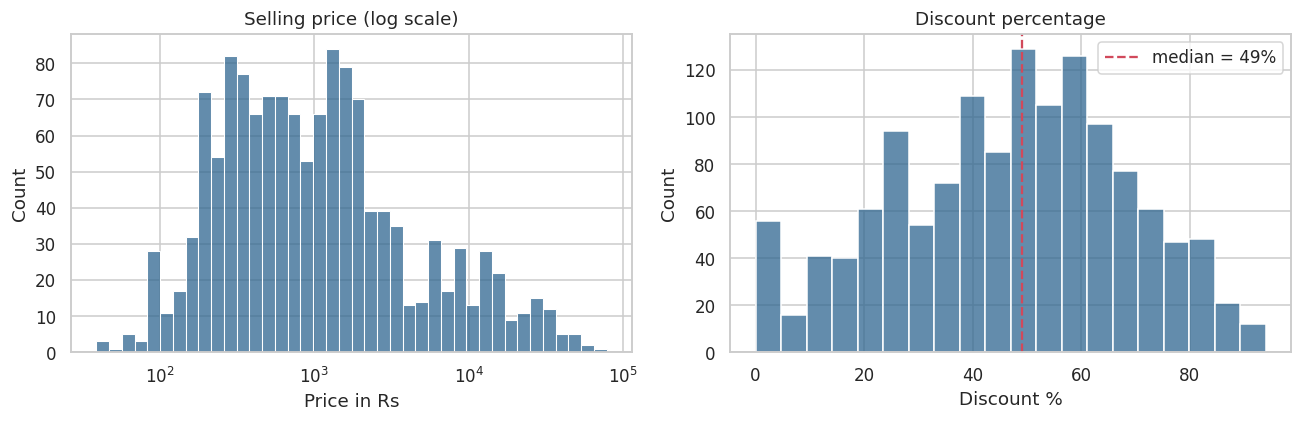

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["discounted_price"], bins=40, log_scale=True, color=MAIN, ax=axes[0])
axes[0].set_title("Selling price (log scale)")
axes[0].set_xlabel("Price in Rs")

sns.histplot(df["discount_pct"], bins=20, color=MAIN, ax=axes[1])
axes[1].axvline(df["discount_pct"].median(), color=ACCENT, linestyle="--", label=f"median = {df['discount_pct'].median():.0f}%")
axes[1].set_title("Discount percentage")
axes[1].set_xlabel("Discount %")
axes[1].legend()

plt.tight_layout()
plt.savefig("../images/01_price_discount_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
print("Median selling price: Rs", df["discounted_price"].median())
print("Mean selling price:   Rs", round(df["discounted_price"].mean()))
print("Products with 60%+ discount:", round((df["discount_pct"] >= 60).mean() * 100, 1), "%")
print("Products with under 20% discount:", round((df["discount_pct"] < 20).mean() * 100, 1), "%")

Median selling price: Rs 899.0
Mean selling price:   Rs 3305
Products with 60%+ discount: 31.4 %
Products with under 20% discount: 12.0 %


**What I see:**
- Prices cover a huge range, which is why the left chart uses a log scale.
- Discounts are deep in general: 31.4% of products have a 60% or higher discount and only 12% have less than 20%.
- The "actual price" is the listed MRP, so a big discount does not always mean a real saving.

## 3. Category analysis

In [5]:
main_cat = (df.groupby("main_category")
              .agg(products=("product_id", "count"),
                   median_price=("discounted_price", "median"),
                   avg_discount=("discount_pct", "mean"),
                   avg_rating=("rating", "mean"),
                   total_ratings=("rating_count", "sum"))
              .round(2)
              .sort_values("products", ascending=False))
main_cat

,products,median_price,avg_discount,avg_rating,total_ratings
main_category,,,,,
Electronics,490,1384.0,49.91,4.08,14208441.0
Home&Kitchen,448,1199.0,40.12,4.04,2991069.0
Computers&Accessories,375,399.0,53.20,4.15,6335182.0
OfficeProducts,31,178.0,12.35,4.31,149675.0
MusicalInstruments,2,638.0,46.00,3.90,88882.0
HomeImprovement,2,337.0,57.50,4.25,8566.0
Car&Motorbike,1,2339.0,42.00,3.80,1118.0
Health&PersonalCare,1,899.0,53.00,4.00,3663.0
Toys&Games,1,150.0,0.00,4.30,15867.0


**What I see:**
- Electronics (490), Home&Kitchen (448) and Computers&Accessories (375) cover 1,313 of the 1,351 products. The other six categories have 31 products or fewer, so their averages (for example Toys&Games with a single product) should not be trusted.
- Computers&Accessories has the highest average discount (53.2%) and the lowest median price (Rs 399). Most of it is cables and other accessories, which are cheap and heavily discounted.
- Home&Kitchen has the lowest discount (40.1%) and the lowest rating (4.04) of the three big categories.
- Electronics has about 60% of all ratings in the data (14.2 million out of 23.8 million), so it is the most rated category.

In [6]:
sub_cat = (df.groupby("sub_category")
             .agg(products=("product_id", "count"),
                  avg_price=("discounted_price", "mean"),
                  avg_discount=("discount_pct", "mean"),
                  avg_rating=("rating", "mean"),
                  total_ratings=("rating_count", "sum"))
             .round(2))
sub_cat = sub_cat[sub_cat["products"] >= 15].sort_values("avg_discount", ascending=False)
sub_cat

,products,avg_price,avg_discount,avg_rating,total_ratings
sub_category,,,,,
WearableTechnology,62,2360.21,69.71,4.01,1227989.0
"Headphones,Earbuds&Accessories",63,959.65,59.49,3.92,4548406.0
Accessories&Peripherals,307,526.91,55.41,4.14,3741108.0
HomeAudio,16,1546.50,49.69,4.07,293704.0
"HomeTheater,TV&Video",156,10540.24,49.39,4.07,2371410.0
Cameras&Photography,16,1272.00,47.56,4.12,322657.0
NetworkingDevices,30,1157.13,47.20,4.16,1346612.0
ExternalDevices&DataStorage,18,2151.39,46.89,4.32,1037012.0
HomeStorage&Organization,16,358.00,46.06,4.03,53765.0


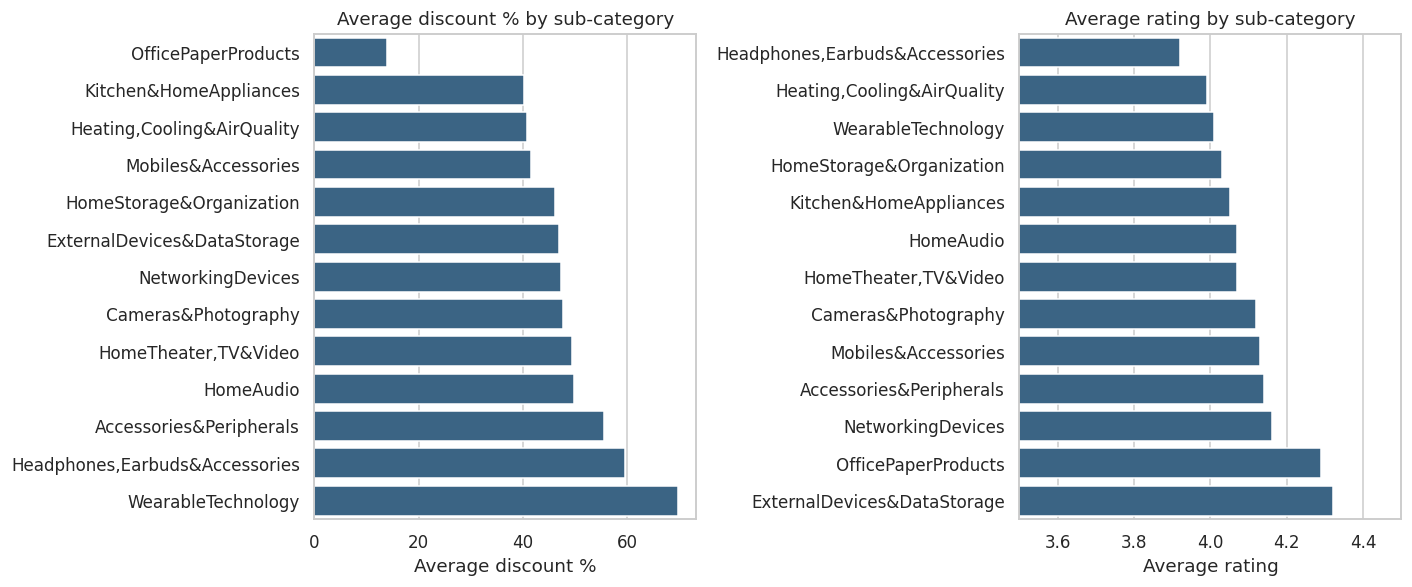

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

order = sub_cat.sort_values("avg_discount").index
sns.barplot(x=sub_cat.loc[order, "avg_discount"], y=order, color=MAIN, ax=axes[0])
axes[0].set_title("Average discount % by sub-category")
axes[0].set_xlabel("Average discount %")
axes[0].set_ylabel("")

order2 = sub_cat.sort_values("avg_rating").index
sns.barplot(x=sub_cat.loc[order2, "avg_rating"], y=order2, color=MAIN, ax=axes[1])
axes[1].set_xlim(3.5, 4.5)
axes[1].set_title("Average rating by sub-category")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../images/02_subcategory_discount_rating.png", dpi=150, bbox_inches="tight")
plt.show()

**What I see:**
- Wearable Technology has the highest average discount (69.7%), then Headphones/Earbuds (59.5%) and Accessories & Peripherals (55.4%). Office Paper Products is barely discounted (14%).
- The most discounted sub-categories are not the best rated. Headphones, Earbuds & Accessories has the lowest average rating (3.92) and Wearables (4.01) is below the overall mean of 4.09.
- External Devices & Data Storage (4.32) and Office Paper Products (4.29) have the best ratings, with average or low discounts (47% and 14%).

## 4. Ratings

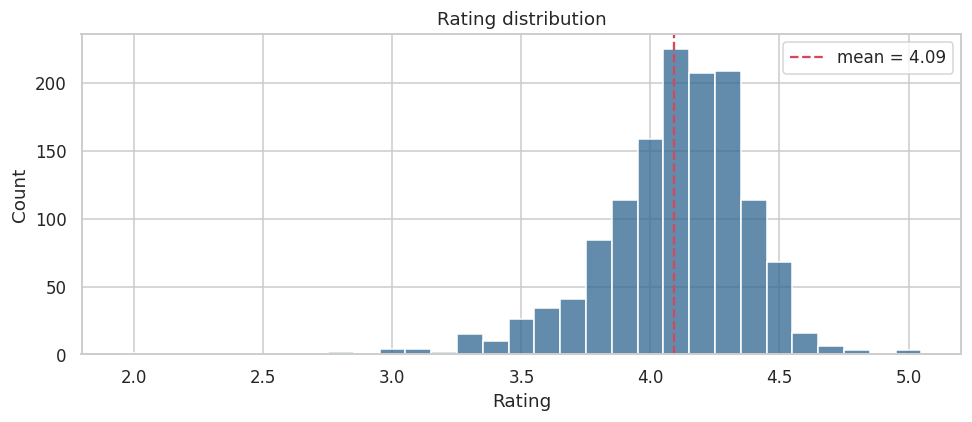

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["rating"].dropna(), bins=np.arange(1.95, 5.1, 0.1), color=MAIN, ax=ax)
ax.axvline(df["rating"].mean(), color=ACCENT, linestyle="--", label=f"mean = {df['rating'].mean():.2f}")
ax.set_title("Rating distribution")
ax.set_xlabel("Rating")
ax.legend()
plt.tight_layout()
plt.savefig("../images/03_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
r = df["rating"].dropna()
print("Mean rating:", round(r.mean(), 2), "| Median:", r.median())
print("Rating 3.9 to 4.3:", round(r.between(3.9, 4.3).mean() * 100, 1), "% of products")
print("Rating below 3.5:", (r < 3.5).sum(), "products")
print("Rating 4.5 or above:", (r >= 4.5).sum(), "products")

Mean rating: 4.09 | Median: 4.1
Rating 3.9 to 4.3: 67.7 % of products
Rating below 3.5: 41 products
Rating 4.5 or above: 96 products


**What I see:**
- Ratings are packed together. About 68% of the products (914 of 1,350) sit between 3.9 and 4.3, so even a difference of 0.1 or 0.2 separates products quite clearly.
- Only 41 products are below 3.5 and 96 are rated 4.5 or more.

## 5. Does a bigger discount mean a lower rating?

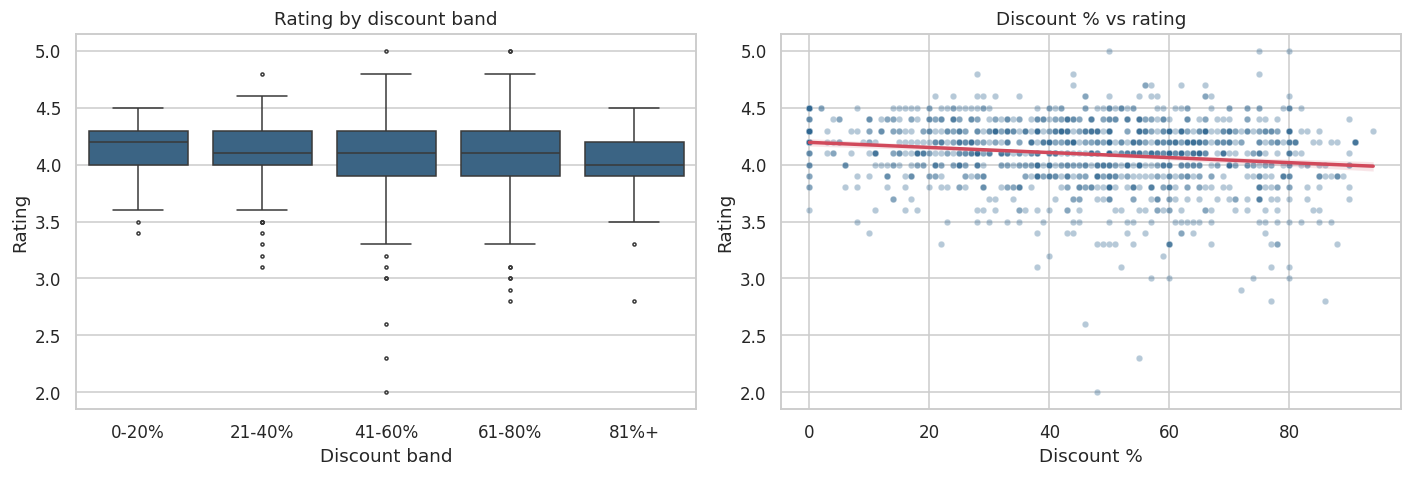

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="discount_band", y="rating", color=MAIN, ax=axes[0], fliersize=2)
axes[0].set_title("Rating by discount band")
axes[0].set_xlabel("Discount band")
axes[0].set_ylabel("Rating")

sns.scatterplot(data=df, x="discount_pct", y="rating", alpha=0.35, color=MAIN, s=18, ax=axes[1])
sns.regplot(data=df, x="discount_pct", y="rating", scatter=False, color=ACCENT, ax=axes[1])
axes[1].set_title("Discount % vs rating")
axes[1].set_xlabel("Discount %")
axes[1].set_ylabel("Rating")

plt.tight_layout()
plt.savefig("../images/04_discount_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
by_disc = (df.groupby("discount_band", observed=True)
             .agg(products=("product_id", "count"),
                  avg_rating=("rating", "mean"),
                  median_rating_count=("rating_count", "median"))
             .round(2))
by_disc

,products,avg_rating,median_rating_count
discount_band,,,
0-20%,176,4.17,6636.5
21-40%,329,4.13,7241.0
41-60%,469,4.07,3025.0
61-80%,327,4.07,4149.0
81%+,50,3.97,3811.5


In [12]:
# Spearman is better than Pearson here because rating_count is very skewed
corr = df[["discounted_price", "discount_pct", "rating", "rating_count"]].corr(method="spearman").round(3)
corr

,discounted_price,discount_pct,rating,rating_count
discounted_price,1.000,-0.367,0.077,0.146
discount_pct,-0.367,1.000,-0.150,-0.131
rating,0.077,-0.150,1.000,0.193
rating_count,0.146,-0.131,0.193,1.000


**What I see:**
- Average rating goes down slowly as the discount goes up: 4.17 in the 0-20% band, 4.07 in the 41-60% and 61-80% bands, and 3.97 in the 81%+ band (only 50 products).
- The Spearman correlation between discount % and rating is -0.15. That is a weak negative relationship: heavily discounted products are rated a little lower on average, but discount alone explains very little.
- Products rated below 3.5 have an average discount of 58.8%, while products rated 4.5 or more have 42.6% (overall average is 46.7%).
- Discount % is also negatively related to price (-0.37), which means cheaper products get bigger percentage discounts.

This does not prove that discounts cause low ratings. It only shows that the two move together a little.

## 6. Price bands

In [13]:
by_price = (df.groupby("price_band", observed=True)
              .agg(products=("product_id", "count"),
                   avg_discount=("discount_pct", "mean"),
                   avg_rating=("rating", "mean"),
                   median_rating_count=("rating_count", "median"))
              .round(2))
by_price

,products,avg_discount,avg_rating,median_rating_count
price_band,,,,
Under 200,160,55.79,4.04,3095.0
200-500,341,54.50,4.08,2685.0
500-1000,237,46.04,4.11,6183.0
1000-2000,262,45.08,4.07,8955.0
2000-5000,148,40.85,4.08,4159.0
5000+,203,33.41,4.17,6753.0


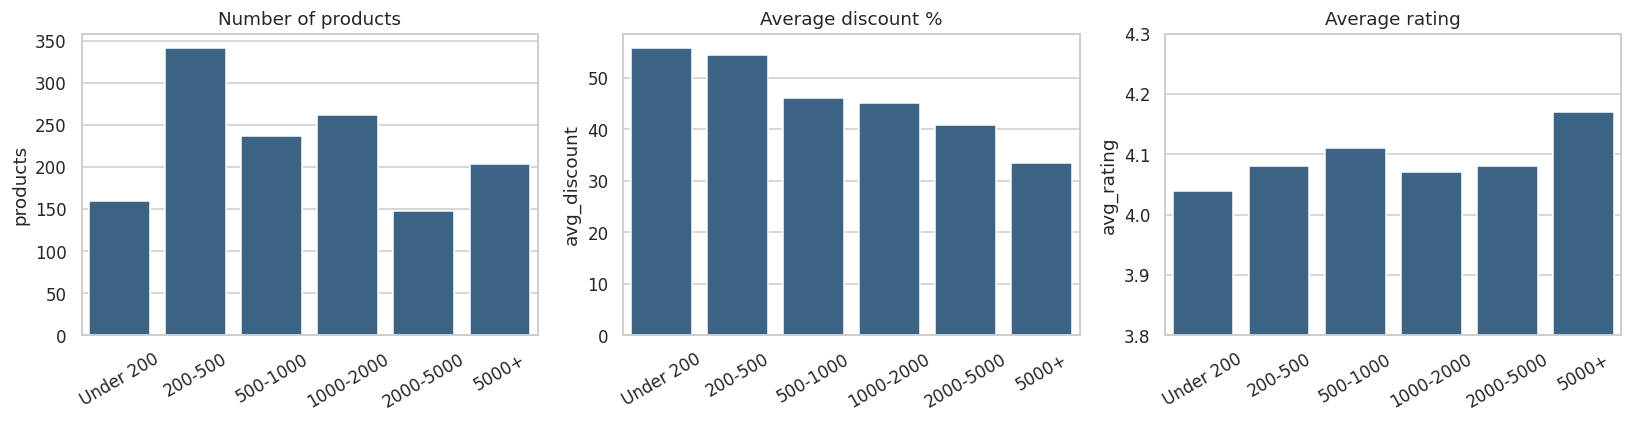

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(x=by_price.index, y=by_price["products"], color=MAIN, ax=axes[0])
axes[0].set_title("Number of products")
axes[0].set_xlabel("")

sns.barplot(x=by_price.index, y=by_price["avg_discount"], color=MAIN, ax=axes[1])
axes[1].set_title("Average discount %")
axes[1].set_xlabel("")

sns.barplot(x=by_price.index, y=by_price["avg_rating"], color=MAIN, ax=axes[2])
axes[2].set_ylim(3.8, 4.3)
axes[2].set_title("Average rating")
axes[2].set_xlabel("")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../images/05_price_band_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**What I see:**
- Cheap products carry the biggest discounts: about 55% on average for the Under 200 and 200-500 bands, against 33% for the 5000+ band.
- Rating hardly changes with price (4.04 to 4.17). The 5000+ band has the highest average rating and the Under 200 band the lowest, but the gap is small.
- The 200-500 band has the most products (341). Products in the 1000-2000 band have the highest median rating count (8,955), so that band looks the most reviewed.

## 7. Brands

In [15]:
brand = (df.groupby("brand")
           .agg(products=("product_id", "count"),
                avg_discount=("discount_pct", "mean"),
                avg_rating=("rating", "mean"),
                total_ratings=("rating_count", "sum"))
           .round(2))

# only brands with at least 10 products, otherwise the average is not reliable
brand10 = brand[brand["products"] >= 10].sort_values("avg_rating", ascending=False)
print("Brands with 10+ products:", len(brand10))
brand10

Brands with 10+ products: 37


,products,avg_discount,avg_rating,total_ratings
brand,,,,
Logitech,15,26.67,4.38,349817.0
SanDisk,16,55.06,4.37,1358815.0
Duracell,15,32.40,4.35,126165.0
Classmate,12,5.50,4.35,59154.0
TP-Link,18,43.11,4.31,1317925.0
AmazonBasics,48,55.56,4.26,2408204.0
Philips,23,16.17,4.25,215549.0
MI,24,31.88,4.25,971394.0
Fire-Boltt,21,80.10,4.23,418237.0


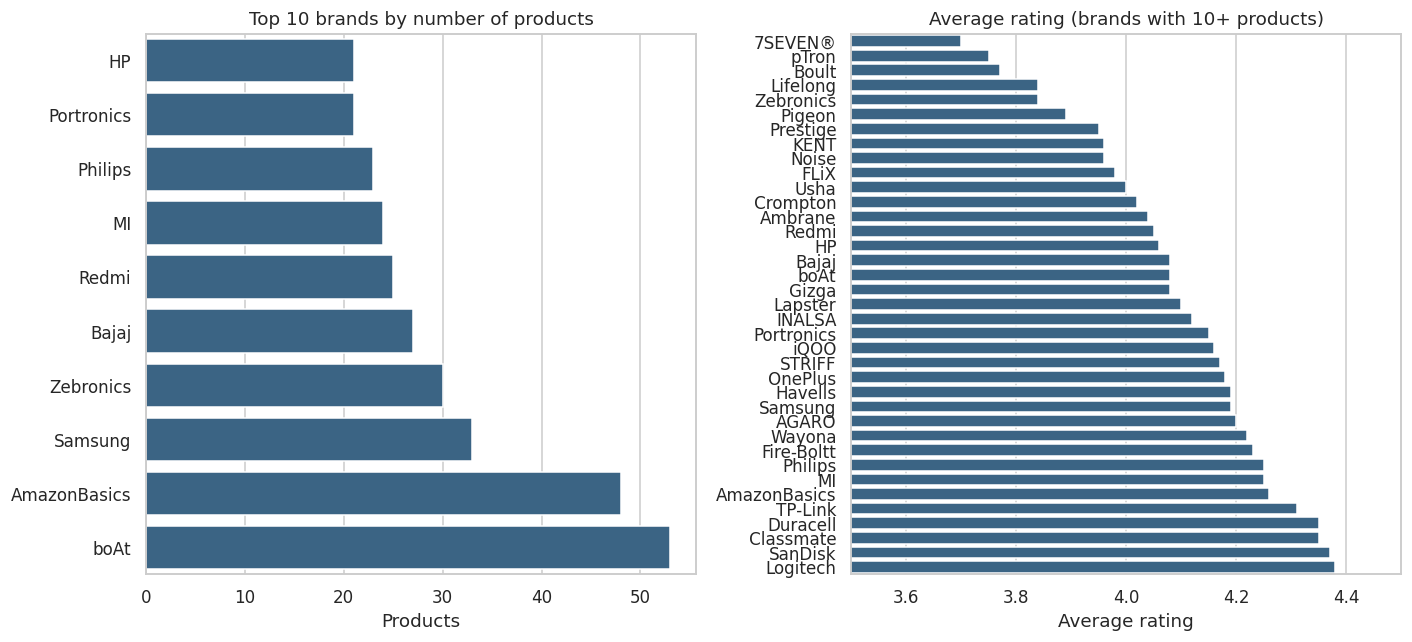

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_count = brand.sort_values("products", ascending=False).head(10).sort_values("products")
sns.barplot(x=top_count["products"], y=top_count.index, color=MAIN, ax=axes[0])
axes[0].set_title("Top 10 brands by number of products")
axes[0].set_xlabel("Products")
axes[0].set_ylabel("")

b = brand10.sort_values("avg_rating")
sns.barplot(x=b["avg_rating"], y=b.index, color=MAIN, ax=axes[1])
axes[1].set_xlim(3.5, 4.5)
axes[1].set_title("Average rating (brands with 10+ products)")
axes[1].set_xlabel("Average rating")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../images/06_brand_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

**What I see:**
- boAt (53 products) and AmazonBasics (48) have the most listings, followed by Samsung (33), Zebronics (30) and Bajaj (27).
- Among the 37 brands with 10+ products, Logitech (4.38), SanDisk (4.37), Duracell and Classmate (both 4.35) have the best average ratings. The lowest are 7SEVEN (3.70), pTron (3.75), Boult (3.77), Zebronics and Lifelong (both 3.84).
- The same discount-vs-rating pattern shows up at brand level. pTron (80% average discount) and Boult (77%) discount heavily and are rated low, while Logitech (27%), Duracell (32%) and Classmate (5.5%) discount much less and are rated higher.
- boAt has by far the most ratings (about 38 lakh) with an average rating of 4.08.

Remember that the brand is just the first word of the product name, so treat this as an overview.

## 8. Best products (weighted rating)

A 5.0 rating from 3 people should not beat a 4.5 from 2 lakh people. So I use a weighted rating, the same idea IMDb uses for its Top 250:

`weighted = (v / (v + m)) * R + (m / (v + m)) * C`

where `R` = product rating, `v` = its rating count, `C` = mean rating of all products, `m` = minimum votes needed (I use the 75th percentile of rating count).

In [17]:
d = df.dropna(subset=["rating", "rating_count"]).copy()
C = d["rating"].mean()
m = d["rating_count"].quantile(0.75)
v = d["rating_count"]
d["weighted_rating"] = (v / (v + m)) * d["rating"] + (m / (v + m)) * C

print("C =", round(C, 3), "| m =", int(m))
top10 = (d.sort_values("weighted_rating", ascending=False)
          .head(10)[["product_name", "brand", "discounted_price", "rating", "rating_count", "weighted_rating"]]
          .round(3))
top10

C = 4.092 | m = 16051


,product_name,brand,discounted_price,rating,rating_count,weighted_rating
1031,Swiffer Instant Electric Water Heater Faucet T...,Swiffer,1439.0,4.8,53803.0,4.637
764,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,SanDisk,939.0,4.5,205052.0,4.470
23,AmazonBasics USB 2.0 Cable - A-Male to B-Male ...,AmazonBasics,209.0,4.5,107687.0,4.447
718,Crucial BX500 240GB 3D NAND SATA 6.35 cm (2.5-...,Crucial,1815.0,4.5,92925.0,4.440
727,Redgear MP35 Speed-Type Gaming Mousepad (Black...,Redgear,299.0,4.6,33434.0,4.435
182,AmazonBasics USB 2.0 Extension Cable for Perso...,AmazonBasics,299.0,4.5,74977.0,4.428
710,AmazonBasics USB 2.0 - A-Male to A-Female Exte...,AmazonBasics,199.0,4.5,74976.0,4.428
399,Spigen EZ Fit Tempered Glass Screen Protector ...,Spigen,999.0,4.6,26603.0,4.409
646,"Logitech M235 Wireless Mouse, 1000 DPI Optical...",Logitech,699.0,4.5,54405.0,4.407
556,Seagate Expansion 1TB External HDD - USB 3.0 f...,Seagate,4098.0,4.5,50810.0,4.402


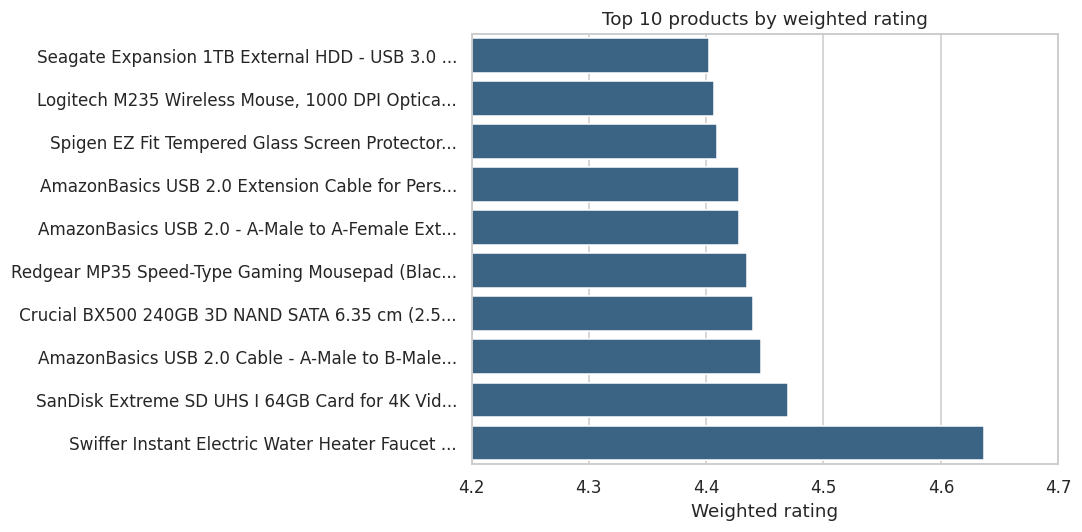

In [18]:
plot_df = top10.copy()
plot_df["short_name"] = plot_df["product_name"].str.slice(0, 45) + "..."
plot_df = plot_df.sort_values("weighted_rating")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=plot_df["weighted_rating"], y=plot_df["short_name"], color=MAIN, ax=ax)
ax.set_xlim(4.2, 4.7)
ax.set_title("Top 10 products by weighted rating")
ax.set_xlabel("Weighted rating")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/07_top_products.png", dpi=150, bbox_inches="tight")
plt.show()

**What I see:**
- The top product is a 4.8-rated "Swiffer Instant Electric Water Heater Faucet" with 53,803 ratings. The brand name looks odd for this product (probably how the seller listed it), but the rating is what the data says.
- After that the list is mostly storage and accessories: SanDisk SD card, AmazonBasics USB cables, Crucial SSD, Redgear mousepad, Logitech mouse and Seagate HDD. All have 4.4+ ratings and tens of thousands of ratings behind them.
- Without the weighted formula, products like the 5.0-rated ones with only 5 or 23 ratings would sit at the top, which makes no sense.

## 9. Products that look overpromised

Heavy discount (70% or more) but a low rating (below 3.8) even though many people rated it (1,000+ ratings). A big discount here may be hiding a weak product, or the "actual price" is inflated.

In [19]:
over = df[(df["discount_pct"] >= 70) & (df["rating"] < 3.8) & (df["rating_count"] >= 1000)]
print("Overpromised products:", len(over))
over_view = (over.sort_values("rating_count", ascending=False)
                 [["product_name", "brand", "sub_category", "discount_pct", "rating", "rating_count"]])
over_view.head(10)

Overpromised products: 22


,product_name,brand,sub_category,discount_pct,rating,rating_count
574,Boult Audio AirBass PowerBuds with Inbuilt Pow...,Boult,"Headphones,Earbuds&Accessories",83,3.7,28324.0
688,"Boult Audio Truebuds with 30H Playtime, IPX7 W...",Boult,"Headphones,Earbuds&Accessories",85,3.6,25910.0
364,"PTron Boom Ultima 4D Dual Driver, in-Ear Gamin...",pTron,"Headphones,Earbuds&Accessories",84,3.6,18202.0
570,GIZGA essentials Universal Silicone Keyboard P...,Gizga,Accessories&Peripherals,87,3.5,15233.0
767,Boult Audio Airbass Propods X TWS Bluetooth Tr...,Boult,"Headphones,Earbuds&Accessories",82,3.5,12966.0
590,Zodo 8. 5 inch LCD E-Writer Electronic Writing...,Zodo,Accessories&Peripherals,80,3.5,9638.0
690,Gizga Essentials Multi-Purpose Portable & Fold...,Gizga,Accessories&Peripherals,73,3.6,6422.0
770,LS LAPSTER Quality Assured Universal Silicone ...,LS,Accessories&Peripherals,88,3.3,5692.0
450,PTron Newly Launched Force X10 Bluetooth Calli...,pTron,WearableTechnology,78,3.3,4415.0
437,PTron Newly Launched Force X10 Bluetooth Calli...,pTron,WearableTechnology,77,3.3,4415.0


In [20]:
print(over["sub_category"].value_counts())

sub_category
Accessories&Peripherals           6
Headphones,Earbuds&Accessories    6
WearableTechnology                3
Kitchen&HomeAppliances            3
HomeTheater,TV&Video              2
Mobiles&Accessories               1
Cameras&Photography               1
Name: count, dtype: int64


**What I see:**
- 22 products have a 70%+ discount, a rating below 3.8 and at least 1,000 ratings.
- 12 of the 22 are in Headphones/Earbuds (6) and Accessories & Peripherals (6), for example Boult, pTron and Gizga products. Another 3 are wearables.
- This could mean the listed "actual price" is inflated in these categories, but the data alone cannot confirm that. For a buyer, the final price and the rating matter more than the discount shown.

## 10. What do customers complain about?

Using the keyword columns from the cleaning notebook: average number of negative keywords per review for each sub-category (15+ products only). Higher means more complaint words in the reviews.

In [21]:
text_sig = (df.groupby("sub_category")
              .agg(products=("product_id", "count"),
                   negative_per_review=("negative_per_review", "mean"),
                   positive_per_review=("positive_per_review", "mean"),
                   avg_rating=("rating", "mean"))
              .round(3))
text_sig = text_sig[text_sig["products"] >= 15].sort_values("negative_per_review", ascending=False)
text_sig

,products,negative_per_review,positive_per_review,avg_rating
sub_category,,,,
"Headphones,Earbuds&Accessories",63,0.227,2.590,3.921
"HomeTheater,TV&Video",156,0.165,1.607,4.071
HomeAudio,16,0.164,1.711,4.069
WearableTechnology,62,0.138,1.935,4.008
NetworkingDevices,30,0.133,1.446,4.163
Kitchen&HomeAppliances,308,0.125,1.387,4.053
"Heating,Cooling&AirQuality",116,0.113,1.276,3.991
Mobiles&Accessories,151,0.110,2.339,4.126
Cameras&Photography,16,0.086,1.500,4.125


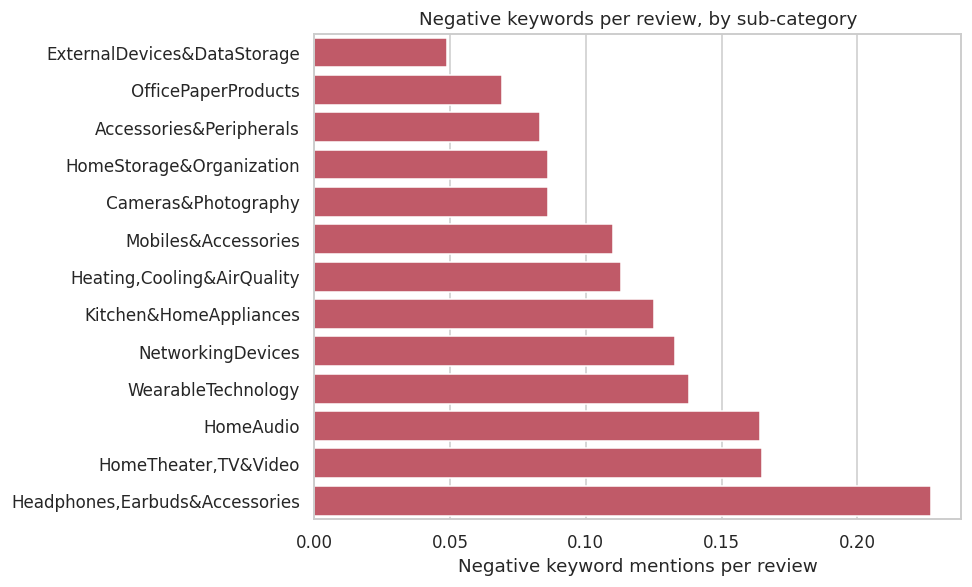

In [22]:
order = text_sig.sort_values("negative_per_review").index
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=text_sig.loc[order, "negative_per_review"], y=order, color=ACCENT, ax=ax)
ax.set_title("Negative keywords per review, by sub-category")
ax.set_xlabel("Negative keyword mentions per review")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/08_negative_keywords_by_subcategory.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# do products with a lower rating really have more complaint words?
df[["rating", "negative_per_review", "positive_per_review"]].corr(method="spearman").round(3)

,rating,negative_per_review,positive_per_review
rating,1.000,-0.151,0.254
negative_per_review,-0.151,1.000,0.026
positive_per_review,0.254,0.026,1.000


**What I see:**
- Headphones & Earbuds has the most complaint words per review (0.23). Home Theater/TV and Home Audio come next (about 0.16). External storage (0.05) and Office Paper Products (0.07) have the fewest.
- Headphones & Earbuds is also the lowest-rated sub-category (3.92), so the review text and the star rating tell the same story.
- Rating and negative words per review have a Spearman correlation of -0.15, so lower-rated products do have more complaint words, but the signal is weak. The keyword method is rough (it cannot understand context) and each product has at most 8 reviews in this file.

## 11. Correlation heatmap

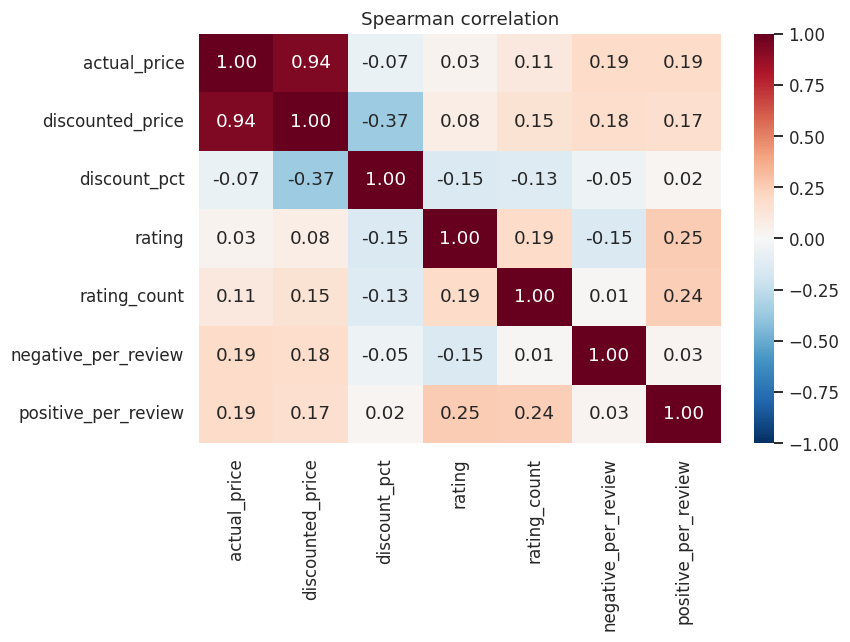

In [24]:
cols = ["actual_price", "discounted_price", "discount_pct", "rating", "rating_count",
        "negative_per_review", "positive_per_review"]
corr_all = df[cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation")
plt.tight_layout()
plt.savefig("../images/09_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**What I see:**
- The only strong relationship is between actual price and discounted price (0.93), which is obvious.
- Everything else is weak: rating vs rating count is 0.19 (better-rated products collect more ratings), discount vs rating is -0.15, rating vs negative words is -0.15.
- So price and discount alone do not explain the rating.

## 12. Save summary tables

In [25]:
main_cat.to_csv("../reports/category_summary.csv")
sub_cat.to_csv("../reports/subcategory_summary.csv")
brand10.to_csv("../reports/brand_summary.csv")
top10.to_csv("../reports/top10_products_weighted_rating.csv", index=False)
over_view.to_csv("../reports/overpromised_products.csv", index=False)
print("Saved 5 summary tables in reports/")

Saved 5 summary tables in reports/


## Conclusion

**Key findings**
1. Discounts are deep and common. The median discount is 49% and 31% of products have 60% or more. Cheaper products get bigger percentage discounts (correlation with price is -0.37).
2. Heavy discount goes with slightly lower ratings (4.17 in the 0-20% band vs 3.97 at 81%+), but the relationship is weak (-0.15).
3. Headphones/earbuds and wearables are the weak spot. They have the highest discounts, the lowest ratings, the most complaint words, and 9 of the 22 "overpromised" products.
4. Storage, cables and accessories from established brands (SanDisk, Logitech, AmazonBasics) show the most consistent high ratings.
5. Electronics accounts for about 60% of all ratings in the data, so it dominates customer activity.

**What this means**
- For a buyer: check the weighted rating and the number of ratings, not just the discount. Be extra careful with 80%+ discounts in headphones and wearables.
- For a seller or category manager: deep discounts in headphones and wearables are not translating into good ratings, so product quality is probably the bigger issue there.

**Limitations**
- `rating_count` is not sales, only a rough measure of popularity.
- Only up to 8 reviews per product are included in the file, and the keyword method is simple.
- Brand is taken from the first word of the product name.
- The data is one snapshot with no dates, so I could not look at trends over time.
- Correlation is not causation.